In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/processed/reddit_posts_cleaned.csv")

df.head()

,keyword,title,subreddit,timestamp,post_url,scrape_date,batch_number,source,clean_title,location,skill,role
0,developersindia hiring,How's Infosys for starters 😳,r/IndiaTech,2026-03-10T07:42:32+00:00,https://old.reddit.com/r/IndiaTech/comments/1r...,NaN,NaN,NaN,hows infosys for starters,Unknown,Unknown,Software Engineer
1,developersindia hiring,Who's hiring? - Monthly Megathread - June 2026,r/developersIndia,2026-06-01T04:32:05+00:00,https://old.reddit.com/r/developersIndia/comme...,NaN,NaN,NaN,whos hiring monthly megathread june 2026,Unknown,Unknown,Software Engineer
2,developersindia hiring,Who's hiring? - Monthly Megathread - February ...,r/developersIndia,2026-02-01T04:32:29+00:00,https://old.reddit.com/r/developersIndia/comme...,NaN,NaN,NaN,whos hiring monthly megathread february 2026,Unknown,Unknown,Software Engineer
3,developersindia hiring,Who's looking for work? - Monthly Megathread -...,r/developersIndia,2026-06-01T04:30:14+00:00,https://old.reddit.com/r/developersIndia/comme...,NaN,NaN,NaN,whos looking for work monthly megathread june ...,Unknown,Unknown,Software Engineer
4,developersindia hiring,Who's hiring? - Monthly Megathread - May 2026,r/developersIndia,2026-05-01T04:32:13+00:00,https://old.reddit.com/r/developersIndia/comme...,NaN,NaN,NaN,whos hiring monthly megathread may 2026,Unknown,Unknown,Software Engineer


# Part 1 – Top Subreddits

In [3]:
subreddit_counts = df["subreddit"].value_counts().head(10)

subreddit_counts

subreddit
r/developersIndia          200
r/Btechtards                37
r/BPOinPH                   36
r/resumes                   35
r/InternshipsIndia          28
r/cscareerquestions         28
r/technology                24
r/Indiajobs                 22
r/india                     21
r/BestofRedditorUpdates     21
Name: count, dtype: int64

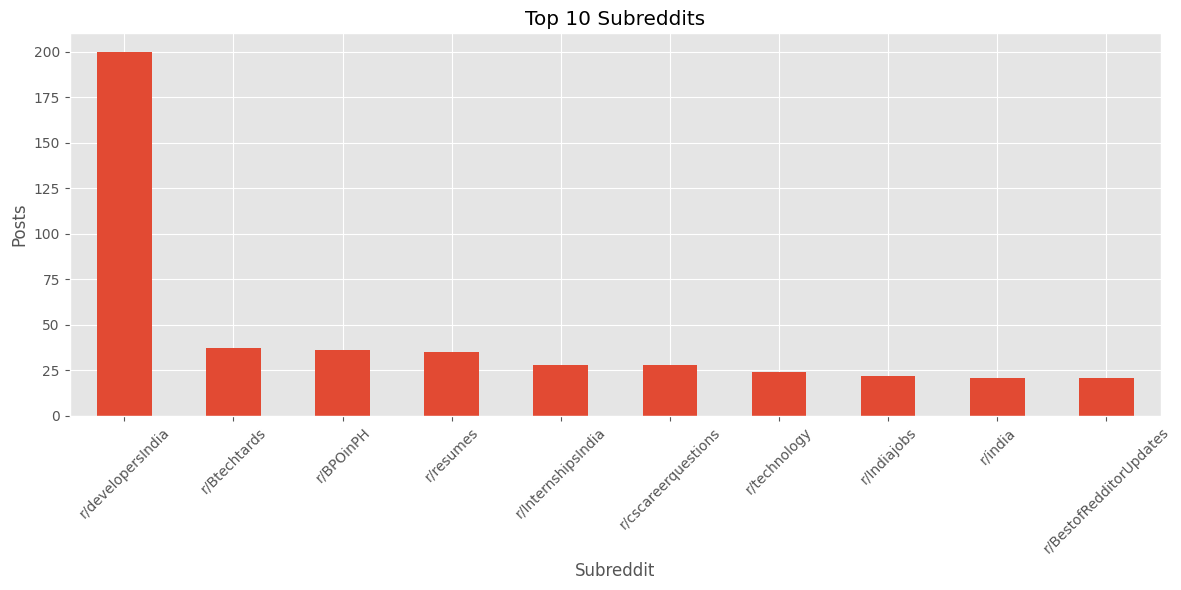

In [4]:
plt.figure(figsize=(12,6))

subreddit_counts.plot(
    kind="bar"
)

plt.title("Top 10 Subreddits")

plt.xlabel("Subreddit")

plt.ylabel("Posts")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../reports/figures/top_subreddits.png")

plt.show()

# Part 2 – Role Distribution

In [5]:
role_counts = (
    df["role"]
    .value_counts()
    .drop("Unknown", errors="ignore")
)

role_counts

role
Software Engineer                                            223
Intern                                                       135
Fresher                                                       86
Data Analyst                                                  55
Fresher, Software Engineer                                    55
                                                            ... 
AI Engineer, Frontend Developer                                1
AI Engineer, Frontend Developer, Software Engineer             1
Frontend Developer, Full Stack Developer                       1
DevOps Engineer, Frontend Developer, Full Stack Developer      1
Fresher, Frontend Developer                                    1
Name: count, Length: 90, dtype: int64

plt.figure(figsize=(8,6))

role_counts.plot(
    kind="bar"
)

plt.title("Job Roles")

plt.xlabel("Role")

plt.ylabel("Count")

plt.tight_layout()

plt.savefig("../reports/figures/dashboard_roles.png")

plt.show()

# Part 3 – Skill Distribution

In [6]:
skill_counts = (
    df["skill"]
    .value_counts()
    .drop("Unknown", errors="ignore")
)

skill_counts

skill
Artificial Intelligence                      321
Python                                        48
Data Science                                  45
Artificial Intelligence, Machine Learning     41
Machine Learning                              36
                                            ... 
Artificial Intelligence, Python, SQL           1
Data Engineering, JavaScript                   1
C++                                            1
Artificial Intelligence, Data Engineering      1
Artificial Intelligence, Cloud, Python         1
Name: count, Length: 62, dtype: int64

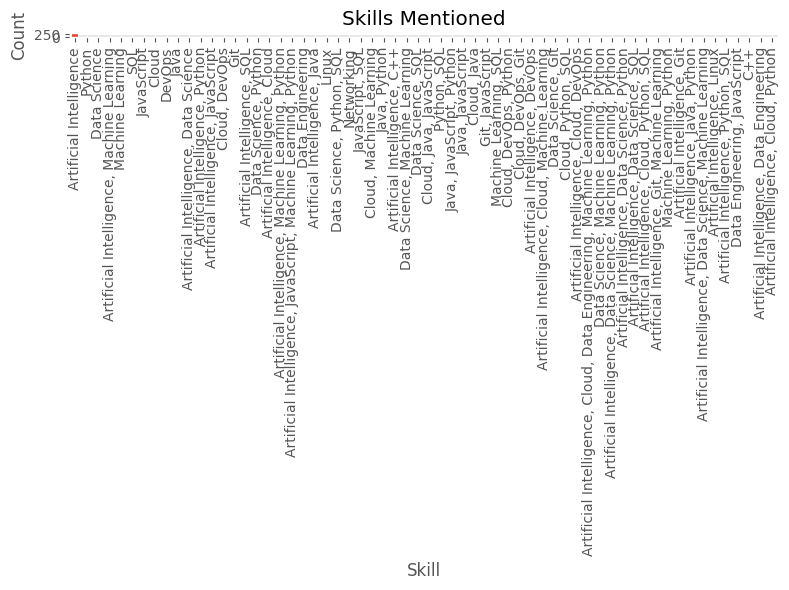

In [7]:
plt.figure(figsize=(8,6))

skill_counts.plot(
    kind="bar"
)

plt.title("Skills Mentioned")

plt.xlabel("Skill")

plt.ylabel("Count")

plt.tight_layout()

plt.savefig("../reports/figures/dashboard_skills.png")

plt.show()

# Part 4 – Location Distribution

In [8]:
location_counts = (
    df["location"]
    .value_counts()
    .drop("Unknown", errors="ignore")
)

location_counts

location
Remote                                 277
Bangalore                               45
Hyderabad                               42
Mumbai                                  25
Delhi                                   23
Pune                                    22
Chennai                                 20
Kolkata                                 20
Ahmedabad                               20
Noida                                   19
Gurgaon                                 18
Bangalore, Remote                        5
Goa                                      4
Chennai, Remote                          2
Hyderabad, Remote                        2
Hybrid                                   2
Delhi, Noida                             2
Bangalore, Jammu                         1
Delhi, Gurgaon, Hyderabad                1
Bangalore, Hybrid                        1
Lucknow                                  1
Hyderabad, Mumbai                        1
Mumbai, Pune                             1
Ja

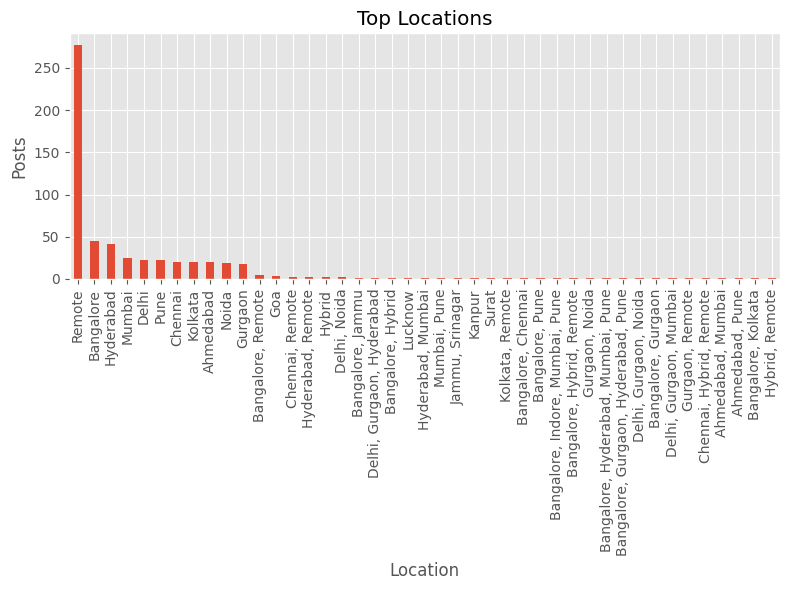

In [9]:
plt.figure(figsize=(8,6))

location_counts.plot(
    kind="bar"
)

plt.title("Top Locations")

plt.xlabel("Location")

plt.ylabel("Posts")

plt.tight_layout()

plt.savefig("../reports/figures/dashboard_locations.png")

plt.show()

# Part 5 – Role vs Location (Cross Analysis)

In [10]:
cross = pd.crosstab(
    df["role"],
    df["location"]
)

cross

location,Ahmedabad,"Ahmedabad, Mumbai","Ahmedabad, Pune",Bangalore,"Bangalore, Chennai","Bangalore, Gurgaon","Bangalore, Gurgaon, Hyderabad, Pune","Bangalore, Hybrid","Bangalore, Hybrid, Remote","Bangalore, Hyderabad, Mumbai, Pune",...,Kolkata,"Kolkata, Remote",Lucknow,Mumbai,"Mumbai, Pune",Noida,Pune,Remote,Surat,Unknown
role,,,,,,,,,,,,,,,,,,,,,
AI Engineer,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,12,0,13
"AI Engineer, Backend Developer",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
"AI Engineer, Backend Developer, Intern",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,2,0,0
"AI Engineer, Backend Developer, Software Engineer",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
"AI Engineer, Cloud Engineer",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Mobile Developer, Software Engineer",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,28
QA Engineer,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
Software Engineer,0,0,0,18,0,0,0,0,0,0,...,0,0,0,1,0,0,0,68,0,134


In [ ]:
cross.plot(
    kind="bar",
    figsize=(12,7)
)

plt.title("Role vs Location")

plt.ylabel("Posts")



plt.savefig("../reports/figures/role_location.png")

plt.show()

# Part 6 – Skill vs Role

In [19]:
cross2 = pd.crosstab(
    df["skill"],
    df["role"]
)

cross2

role,AI Engineer,"AI Engineer, Backend Developer","AI Engineer, Backend Developer, Intern","AI Engineer, Backend Developer, Software Engineer","AI Engineer, Cloud Engineer","AI Engineer, Data Scientist","AI Engineer, Fresher","AI Engineer, Fresher, Intern","AI Engineer, Frontend Developer","AI Engineer, Frontend Developer, Software Engineer",...,"Intern, Security Engineer","Intern, Software Engineer","Intern, Software Engineer, Web Developer",Machine Learning Engineer,"Machine Learning Engineer, Software Engineer","Mobile Developer, Software Engineer",QA Engineer,Software Engineer,"Software Engineer, Web Developer",Unknown
skill,,,,,,,,,,,,,,,,,,,,,
Artificial Intelligence,25,1,2,0,0,0,1,2,1,1,...,0,5,1,0,0,3,0,14,0,182
"Artificial Intelligence, C++",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
"Artificial Intelligence, Cloud",0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
"Artificial Intelligence, Cloud, Data Engineering, Machine Learning, Python",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"Artificial Intelligence, Cloud, DevOps",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Networking,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
Python,0,0,0,0,0,0,0,0,0,0,...,0,3,0,0,0,0,0,13,3,1
"Python, SQL",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


C:\Users\prata\AppData\Local\Temp\ipykernel_28136\943093693.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


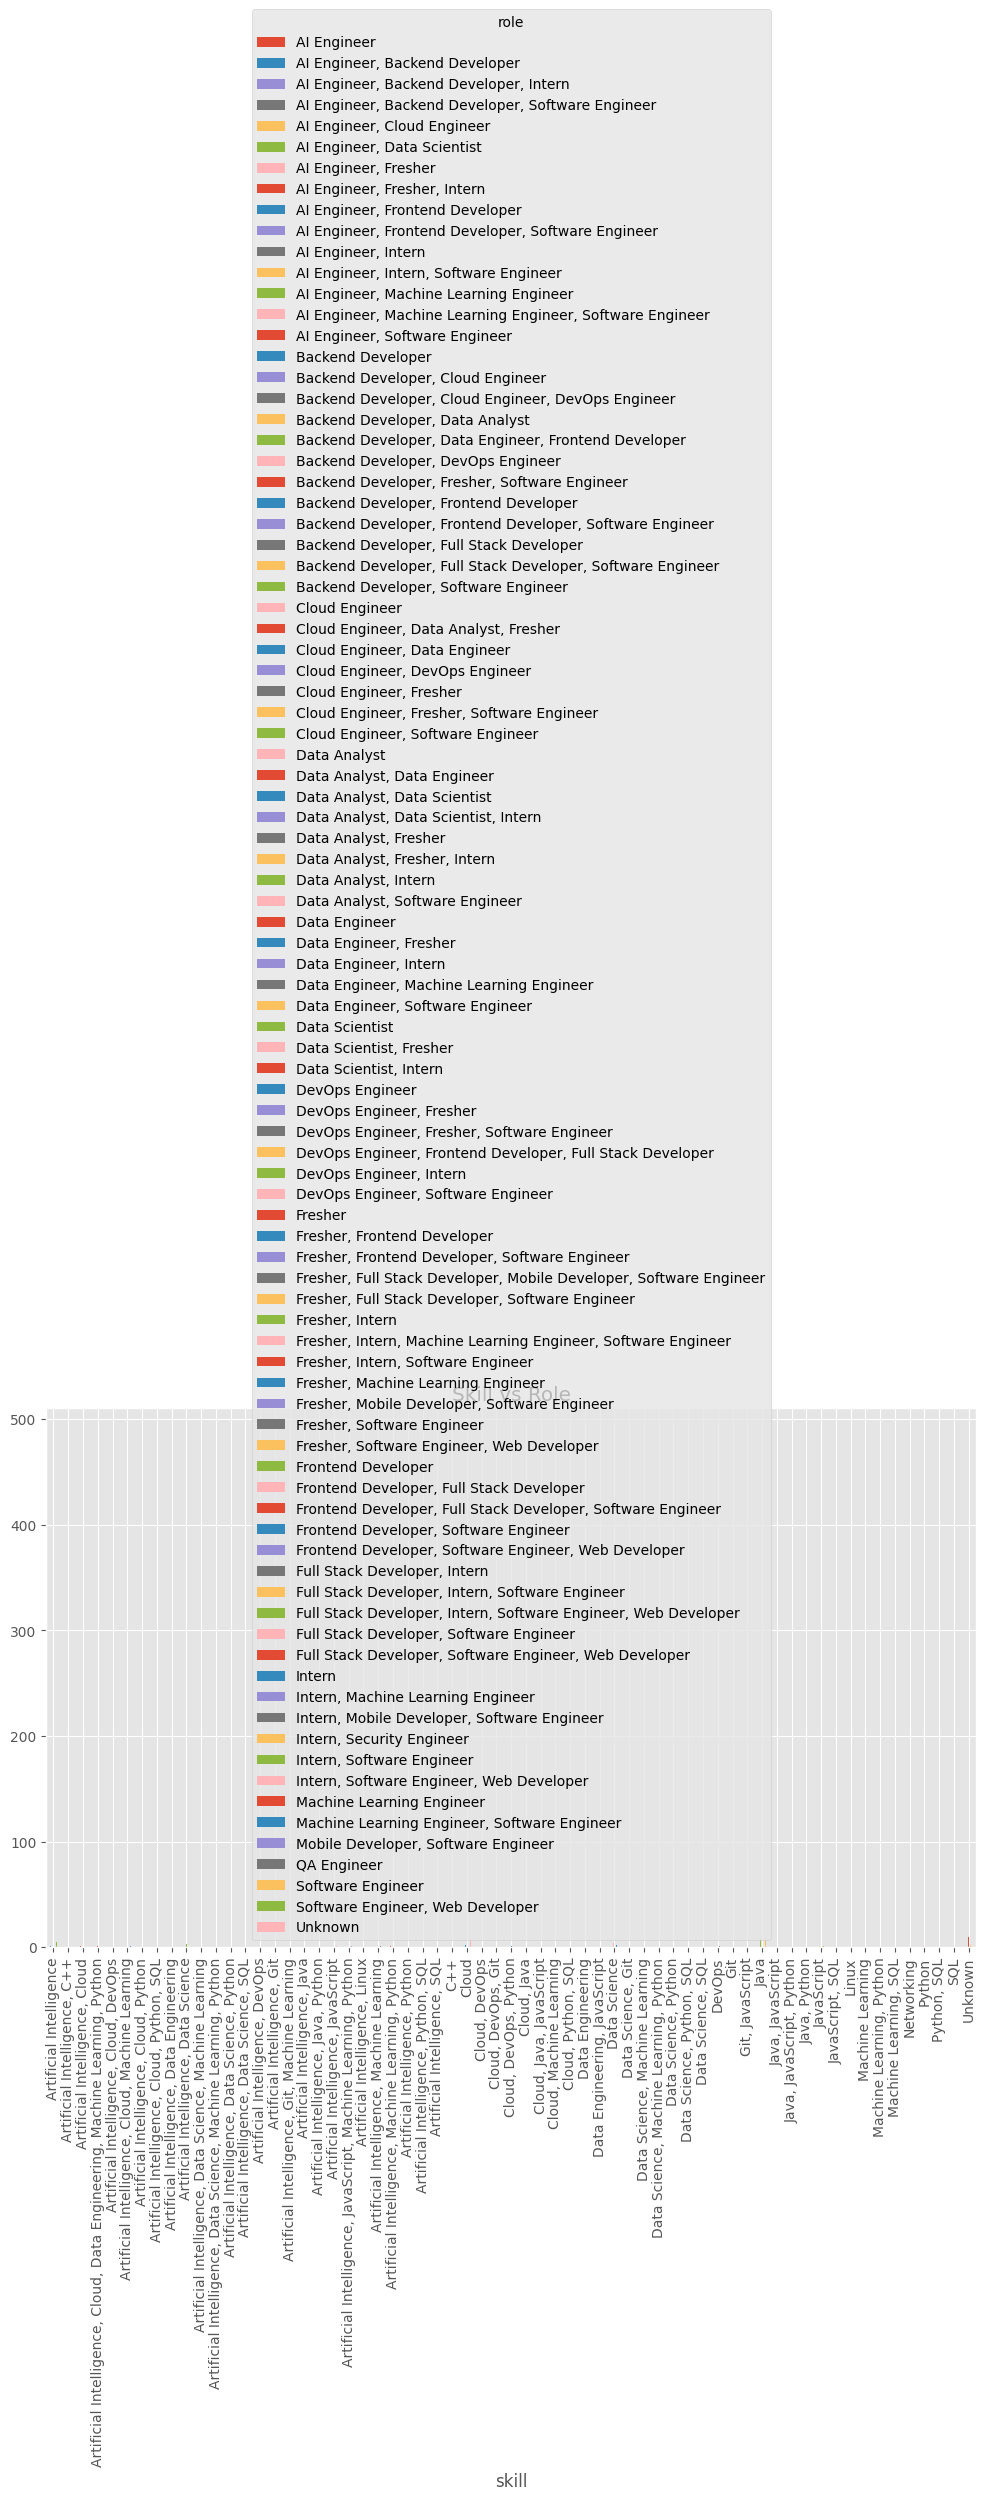

In [20]:
cross2.plot(
    kind="bar",
    figsize=(12,7)
)

plt.title("Skill vs Role")

plt.tight_layout()

plt.savefig("../reports/figures/skill_role.png")

plt.show()

# Part 7 – Dataset Statistics

In [21]:
print("Total Posts :", len(df))
print("Unique Roles :", df["role"].nunique())
print("Unique Skills :", df["skill"].nunique())
print("Unique Locations :", df["location"].nunique())
print("Unique Subreddits :", df["subreddit"].nunique())

Total Posts : 1782
Unique Roles : 91
Unique Skills : 63
Unique Locations : 44
Unique Subreddits : 569


In [22]:
summary = pd.DataFrame({

    "Metric":[
        "Posts",
        "Roles",
        "Skills",
        "Locations",
        "Subreddits"
    ],

    "Value":[
        len(df),
        df["role"].nunique(),
        df["skill"].nunique(),
        df["location"].nunique(),
        df["subreddit"].nunique()
    ]

})

summary

,Metric,Value
0,Posts,1782
1,Roles,91
2,Skills,63
3,Locations,44
4,Subreddits,569


In [23]:
summary.to_csv(
    "../reports/dashboard_summary.csv",
    index=False
)

# Dashboard Insights

## Observations

- Most employment discussions occur in r/developersIndia.
- Software Engineer is the most frequently detected role.
- Artificial Intelligence is the dominant detected skill.
- Bangalore is the most frequently mentioned hiring location.
- Unknown values remain high because the current extraction uses dictionary-based matching.
- The dashboard will become more informative as more Reddit posts are collected over time.